# 8주차 과제

- Colab 환경에서는 마크다운 셀의 보이지 않을 수 있으니, VS Code 등의 로컬환경을 사용하시거나 참고이미지 폴더의 파일들을을 참고하시길 바랍니다.

- 과제 제작과정에서  
    코드 작성은 VS Code에서 진행되었습니다.  
    Tableau 과제 제작은 Tableau Public의 데스크탑 버전에서 진행되었습니다.

- 출력 형태를 보며 display를 활용한 출력, print를 활용한 출력을 적절하게 사용해주시길 바랍니다.  
※ 이를 준수하지 않을 시에 오답의 요소가 될 수 있습니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Q1. Python 데이터 전처리

In [2]:
''' 데이터 확인용 코드 셀입니다 '''
''' 참고용으로만 활용하시면 됩니다. '''

import pandas as pd
ab_df = pd.read_csv('./data_과제/ab_testing_prep.csv')
display(ab_df.head())

,user_id,Impression,Click,Purchase,Earning,test_group
0,1,82529.459271,6090.077317,665.211255,2311.277143,control
1,2,98050.451926,3382.861786,315.084895,1742.806855,control
2,3,82696.023549,4167.965750,458.083738,1797.827447,control
3,4,109914.400398,4910.882240,487.090773,1696.229178,control
4,5,108457.762630,5987.655811,441.034050,1543.720179,control


**문제**

1. CVR 컬럼 추가
    - Purchase / Click 식을 통해 계산
    - 데이터 확인
        - CVR 상위 5개 데이터 출력
        - Purchase 상위 10개 데이터 출력
    
2. 데이터 그룹 나누기
    - (1) control group
    - (2) test group

3. 데이터 결측치 확인

In [9]:
''' 정답 코드를 작성해주세요 '''

# "1. CVR 컬럼 추가" 작업을 수행해주세요
ab_df['CVR'] = ab_df['Purchase']/ab_df['Click']

print('CVR 상위 5개 데이터')
display(ab_df.sort_values(by='CVR', ascending=False).head(5))

print('Purchase 상위 10개 데이터')
display(ab_df.sort_values(by='Purchase', ascending=False).head(10))

CVR 상위 5개 데이터


,user_id,Impression,Click,Purchase,Earning,test_group,CVR
67,68,124669.003405,1836.629861,822.599924,2286.714523,test,0.447886
20,21,105493.023207,2189.753157,666.482067,2111.873740,control,0.304364
70,71,158605.920483,2736.410229,748.496608,2189.612669,test,0.273532
69,70,117989.246382,3411.711492,854.129426,2260.630780,test,0.250352
50,51,96331.365434,3860.628358,889.910460,2613.393926,test,0.230509


Purchase 상위 10개 데이터


,user_id,Impression,Click,Purchase,Earning,test_group,CVR
50,51,96331.365434,3860.628358,889.910460,2613.393926,test,0.230509
47,48,125957.116104,4690.569911,855.719803,2563.579756,test,0.182434
69,70,117989.246382,3411.711492,854.129426,2260.630780,test,0.250352
41,42,134775.943363,3635.082422,834.054286,2929.405820,test,0.229446
67,68,124669.003405,1836.629861,822.599924,2286.714523,test,0.447886
15,16,101616.465549,5323.548253,801.795020,2182.161708,control,0.150613
45,46,115923.006949,4213.868620,778.373161,2157.408552,test,0.184717
27,28,136171.271652,5784.321927,772.032879,1704.134541,control,0.133470
44,45,145082.516838,5201.387724,749.860442,2781.697521,test,0.144165
70,71,158605.920483,2736.410229,748.496608,2189.612669,test,0.273532


In [14]:
# "2. 데이터 그룹 나누기" 작업을 수행해주세요
''' 정답 코드를 작성해주세요 '''
control_group = ab_df[ab_df['test_group']=='control']
test_group = ab_df[ab_df['test_group']=='test']

print('데이터 그룹 나누기 결과\n')
print('control 그룹')
display(control_group.head())

print('test 그룹')
display(test_group.head())

데이터 그룹 나누기 결과

control 그룹


,user_id,Impression,Click,Purchase,Earning,test_group,CVR
0,1,82529.459271,6090.077317,665.211255,2311.277143,control,0.109229
1,2,98050.451926,3382.861786,315.084895,1742.806855,control,0.093142
2,3,82696.023549,4167.965750,458.083738,1797.827447,control,0.109906
3,4,109914.400398,4910.882240,487.090773,1696.229178,control,0.099186
4,5,108457.762630,5987.655811,441.034050,1543.720179,control,0.073657


test 그룹


,user_id,Impression,Click,Purchase,Earning,test_group,CVR
40,41,120103.503796,3216.547958,702.160346,1939.611243,test,0.218296
41,42,134775.943363,3635.082422,834.054286,2929.405820,test,0.229446
42,43,107806.620788,3057.143560,422.934258,2526.244877,test,0.138343
43,44,116445.275526,4650.473911,429.033535,2281.428574,test,0.092256
44,45,145082.516838,5201.387724,749.860442,2781.697521,test,0.144165


In [15]:
# 세 번째 출력 결과
# 3. 데이터 결측치 확인
''' 정답 코드를 작성해주세요 '''
print('control_group 결측치 정보')
display(control_group.isnull().sum())

print('test_group 결측치 정보')
display(test_group.isnull().sum())

control_group 결측치 정보


user_id       0
Impression    0
Click         0
Purchase      0
Earning       0
test_group    0
CVR           0
dtype: int64

test_group 결측치 정보


user_id       0
Impression    0
Click         0
Purchase      0
Earning       0
test_group    0
CVR           0
dtype: int64

- 데이터 저장용 Code Cell입니다.
- 해당 Cell은 사용하셔도 되고, 사용하지 않으셔도 무방합니다.

In [3]:
control_group.to_csv('./data_result/Q1_control.csv', index=False) # 데이터 저장
test_group.to_csv('./data_result/Q1_test.csv', index=False) # 데이터 저장

display(pd.read_csv('./data_result/Q1_control.csv').head()) # 데이터 확인
display(pd.read_csv('./data_result/Q1_test.csv').head()) # 데이터 확인

,user_id,Impression,Click,Purchase,Earning,test_group,CVR
0,1,82529.459271,6090.077317,665.211255,2311.277143,control,0.109229
1,2,98050.451926,3382.861786,315.084895,1742.806855,control,0.093142
2,3,82696.023549,4167.965750,458.083738,1797.827447,control,0.109906
3,4,109914.400398,4910.882240,487.090773,1696.229178,control,0.099186
4,5,108457.762630,5987.655811,441.034050,1543.720179,control,0.073657


,user_id,Impression,Click,Purchase,Earning,test_group,CVR
0,41,120103.503796,3216.547958,702.160346,1939.611243,test,0.218296
1,42,134775.943363,3635.082422,834.054286,2929.405820,test,0.229446
2,43,107806.620788,3057.143560,422.934258,2526.244877,test,0.138343
3,44,116445.275526,4650.473911,429.033535,2281.428574,test,0.092256
4,45,145082.516838,5201.387724,749.860442,2781.697521,test,0.144165


## Q2. 함수 선언 : 두 데이터프레임에 대한 t-test

- 문제

- Q1에서 control / test 그룹 데이터를 생성하지 못한 경우,
    - 제공된 Q1_control.csv, Q1_test.csv 사용하여 Q2 문제를 해결하시면 됩니다.
    - Q1 문제를 해결하지 못하여, Q2 문제를 풀지 못하는 경우를 방지하고자 파일을 제공

- **함수 df_analysis**
    - user_id와 test_group을 제외한 컬럼들에 대한 t-test 수행
    - 반복문을 돌며, 유의수준 0.05를 기준으로 귀무가설의 기각/채택에 따른 결론 출력
    - 입력인자
        - (1) Q1에서 만든 Control 그룹
        - (2) Q1에서 만든 Test 그룹
        - (3) 컬럼 리스트
    - 출력 : 각 컬럼에 대한 p-value 결과 출력
    - 반환값 : 없음

- Python 버전, Numpy/Pandas 등 라이브러리 버전에 따라 결과가 일부 다르게 출력될 수 있습니다.

- 문제에서 평가하고자 하는 내용은 라이브러리 활용 능력입니다. 정규성/등분산성에 대해 이론적으로 엄밀한 검정까지는 고려하지 않으셔도 무방합니다.

In [16]:
# 정답 작성
from scipy import stats
def df_analysis(df_1, df_2, column_list):
    ''' 정답을 작성해주세요'''
    for col in column_list:
        statistic, p_value = stats.ttest_ind(df_1[col], df_2[col], equal_var=False)
        print('='*20)
        print(f"\n{col}에 대한 p-value 수행\n")
        if p_value < 0.05:
           print(f"두 집단의 {col}에 대한 p-value 값 : {p_value}")
           print('귀무가설 기각')
           print(f'두 집단의 {col}의 평균값에는 유의미한 차이가 존재한다.\n')
        else:
           print(f"두 집단의 {col}에 대한 p-value 값 : {p_value}")
           print('귀무가설 채택')
           print(f'두 집단에서 {col}의 평균값에는 유의미한 차이가 존재하지 않는다.\n')
    return None

- 함수 출력 결과입니다.
    - Python 버전, Numpy/Pandas 등 라이브러리 버전에 따라 결과가 일부 다르게 출력될 수 있습니다.
    - 각 컬럼에 대해서 아래 값들이 출력됩니다.
        - p-value
        - 귀무가설 채택/기각
        - 결론문장

In [17]:
# 해당 셀은 어떠한 수정도 없이 그대로 출력 바랍니다.
df_analysis(df_1 = control_group,
            df_2 = test_group,
            column_list = ['CVR', 'Click', 'Purchase', 'Earning'])


CVR에 대한 p-value 수행

두 집단의 CVR에 대한 p-value 값 : 0.0025144258183585565
귀무가설 기각
두 집단의 CVR의 평균값에는 유의미한 차이가 존재한다.


Click에 대한 p-value 수행

두 집단의 Click에 대한 p-value 값 : 3.4709315629759006e-05
귀무가설 기각
두 집단의 Click의 평균값에는 유의미한 차이가 존재한다.


Purchase에 대한 p-value 수행

두 집단의 Purchase에 대한 p-value 값 : 0.34942142367866935
귀무가설 채택
두 집단에서 Purchase의 평균값에는 유의미한 차이가 존재하지 않는다.


Earning에 대한 p-value 수행

두 집단의 Earning에 대한 p-value 값 : 3.611097969386056e-14
귀무가설 기각
두 집단의 Earning의 평균값에는 유의미한 차이가 존재한다.



## Q3. SQLite 데이터 처리

**데이터 정보**
- ab_test_data : Tableau 분석 강의 데이터
- user_info : Tableau 분석 강의 데이터

**문제**
- sqlite3를 통해 데이터 전처리 수행
    - 컬럼 추가, 데이터 Join 등의 데이터 전처리
        - sqlite 활용
    - 정보 출력, 데이터 출력 등의 데이터 확인
        - pandas 활용

- 작업내용
    1. ab_test_data / user_info_data SQLite 메모리에 저장  
    2. 두 데이터 Join user_id 기준 join  
    3. Padnas 함수를 통한 데이터 정보 확인

- **첫 번째 작업**
    - ab_test_data 데이터를 SQLite 메모리에 저장 후 정보 출력
        - 데이터 형태
        - 데이터 내용

In [18]:
# 정답 코드를 작성해주세요
# 데이터 정렬 순서도 확인해주시길 바랍니다.

import pandas as pd
import os
import sqlite3
conn = sqlite3.connect(":memory:") # SQLite 데이터베이스에 연결 (메모리 상에 임시 DB 생성)

''' 해당 셀에서는 문제풀이 과정 중에서, 데이터 정보를 확인하는 과정을 수행합니다. '''

''' 정답을 작성해주세요 '''
ab_test_data = pd.read_csv('./data_과제/데이터셋_태블로_웹로그_강의/ab_test_data.csv')
ab_test_data.to_sql('ab_test_data', conn, index=False, if_exists='replace')

query_ab_info = """
SELECT * FROM ab_test_data ab"""
display(f"ab_test 데이터 형태 : {pd.read_sql(query_ab_info, conn).shape}")

display(ab_test_data)

'ab_test 데이터 형태 : (50000, 3)'

,user_id,views,clicks
0,1,869,3
1,2,748,45
2,3,432,47
3,4,679,67
4,5,454,41
...,...,...,...
49995,49996,261,17
49996,49997,93,4
49997,49998,218,3
49998,49999,264,19


- **두 번째 작업**
    - user_info_data 데이터를 SQLite 메모리에 저장 후 정보 출력
        - 데이터 형태
        - 데이터 내용

In [20]:
''' 정답을 작성해주세요 '''
user_info_data = pd.read_csv('./data_과제/데이터셋_태블로_웹로그_강의/user_info_data.csv')
user_info_data.to_sql('user_info_data', conn, index=False, if_exists='replace') # DataFrame을 SQL 테이블로 저장
query_user_info = """
SELECT * FROM user_info_data"""

display(f"user_info 데이터 형태 : {pd.read_sql(query_user_info, conn).shape}")
display(user_info_data)

'user_info 데이터 형태 : (50000, 3)'

,user_id,test_group,age_group
0,1,control,30s
1,2,test,20s
2,3,test,20s
3,4,test,30s
4,5,control,20s
...,...,...,...
49995,49996,test,30s
49996,49997,control,30s
49997,49998,test,30s
49998,49999,test,20s


- 해당 셀에서는 문제풀이 과정 중에서, 데이터 Join하고 확인하는 과정을 수행합니다.
- 참고사항
    - 데이터 정렬 순서 확인
    - 컬럼 순서 확인
    - 데이터 출력 형태 확인

In [21]:
''' 정답을 작성해주세요 '''

query_result = """
SELECT ab.user_id, ab.clicks, ab.views, round(CAST(ab.clicks AS REAL)/ab.views*100, 2) AS CTR, ui.age_group, ui.test_group
FROM ab_test_data ab
JOIN user_info_data ui ON ab.user_id = ui.user_id;"""

df_1 = pd.read_sql(query_result, conn)
df_1

,user_id,clicks,views,CTR,age_group,test_group
0,1,3,869,0.35,30s,control
1,2,45,748,6.02,20s,test
2,3,47,432,10.88,20s,test
3,4,67,679,9.87,30s,test
4,5,41,454,9.03,20s,control
...,...,...,...,...,...,...
49995,49996,17,261,6.51,30s,test
49996,49997,4,93,4.30,30s,control
49997,49998,3,218,1.38,30s,test
49998,49999,19,264,7.20,20s,test


- 세 번째 작업
    - sqlite를 통해 데이터를 전처리한 결과를,  
    Pandas 함수를 통해 확인하는 과정을 수행합니다.

In [22]:
''' 정답을 작성해주세요 '''
display(f"결합 수행 이후 데이터 형태 : {df_1.shape}")
display(df_1.describe())

'결합 수행 이후 데이터 형태 : (50000, 6)'

,user_id,clicks,views,CTR
count,50000.000000,50000.00000,50000.000000,49945.000000
mean,25000.500000,58.35702,1005.536200,5.627645
std,14433.901067,104.23301,1003.510297,6.010080
min,1.000000,0.00000,0.000000,0.000000
25%,12500.750000,6.00000,288.000000,1.420000
50%,25000.500000,23.00000,699.000000,3.770000
75%,37500.250000,66.00000,1394.000000,7.810000
max,50000.000000,2936.00000,10000.000000,73.660000


## Q4. 집단별 상관계수 시각화

**작업 1 : sqlite3를 통해 데이터 전처리를 수행해주세요**
1. df_test : Q3에서 만든 데이터에서 test 그룹만 선택

2. df_control : Q3에서 만든 데이터에서 control 그룹만 선택
    - df_test와 df_control 그룹 생성은 sqlite3를 활용할 것  
    - 해당 과정을 Panas를 통해 진행할 경우 오답으로 처리됩니다.
    - 컬럼 순서도 동일하게 해주시길 바랍니다.

In [10]:
''' 해당 셀에서는 문제풀이 과정 중에서 데이터 전처리와 전처리 결과 확인을 수행합니다. '''

# 정답 작성

import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

# 1) 1) df_test : df_1에서 test 그룹만 선택

''' 정답을 작성해주세요 '''

df_1.to_sql('total_data', conn, index=False, if_exists='replace')
query_test = """
SELECT * FROM total_data
WHERE `test_group` = 'test';
"""
df_test = pd.read_sql(query_test, conn)

print('='*80)
print('df_test 출력')
display(df_test)

# 2) df_control : df_1에서 control 그룹만 선택

''' 정답을 작성해주세요 '''

query_control="""
SELECT * FROM total_data
WHERE `test_group` = 'control';
"""
df_control = pd.read_sql(query_control, conn)

print('='*80)
print('df_control 출력')
display(df_control)

df_test 출력


,user_id,clicks,views,CTR,age_group,test_group
0,2,45,748,6.02,20s,test
1,3,47,432,10.88,20s,test
2,4,67,679,9.87,30s,test
3,8,56,1545,3.62,30s,test
4,9,19,416,4.57,20s,test
...,...,...,...,...,...,...
24942,49993,50,2757,1.81,40s,test
24943,49996,17,261,6.51,30s,test
24944,49998,3,218,1.38,30s,test
24945,49999,19,264,7.20,20s,test


df_control 출력


,user_id,clicks,views,CTR,age_group,test_group
0,1,3,869,0.35,30s,control
1,5,41,454,9.03,20s,control
2,6,208,1072,19.40,30s,control
3,7,493,1801,27.37,10s,control
4,11,0,10,0.00,40s,control
...,...,...,...,...,...,...
25048,49989,37,1548,2.39,20s,control
25049,49992,17,191,8.90,10s,control
25050,49994,2,234,0.85,20s,control
25051,49995,2,1131,0.18,30s,control


**작업 2 : 시각화 수행**
- 집단별 상관계수 시각화 : 출력형태를 보고 작업 진행해주세요
- 시각화 차트 배열, 제목 등의 요소를 동일하게 반영해주세요
- 참고사항
    - 색상 정답 무관
    - 소수 자릿수 정답 무관

<Axes: title={'center': 'control 집단에서의 상관관계'}>

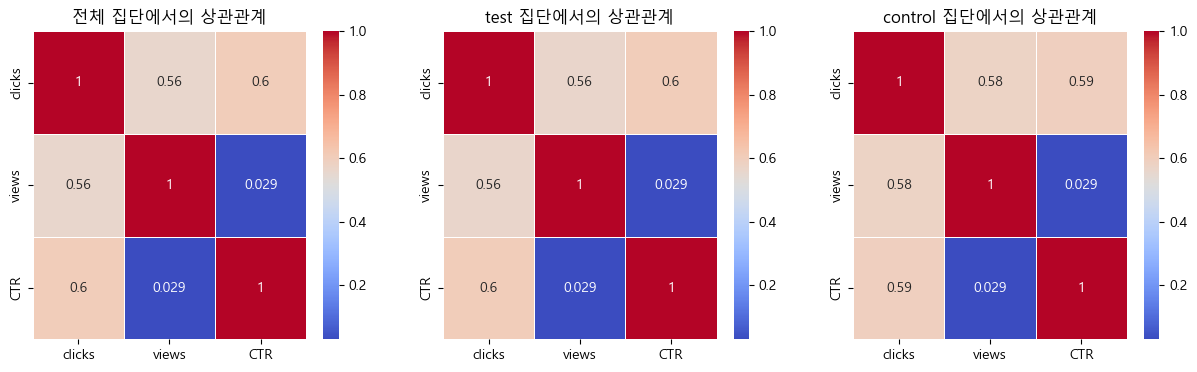

In [ ]:
''' 시각화를 위한 정답 코드를 작성해주세요 '''

plt.figure(figsize=(15,4))

plt.subplot(1,3,1) # 머신러닝 강의 실습12,13,14,15,16_advanced_classifier.ipynb
plt.title('전체 집단에서의 상관관계')
sns.heatmap(df_1[['clicks', 'views','CTR']].corr(), annot=True, cmap='coolwarm', linewidths=0.5) # 차호준 실습3,4,5_basic_classifier.ipynb 시각화

plt.subplot(1,3,2)
plt.title('test 집단에서의 상관관계')
sns.heatmap(df_test[['clicks', 'views','CTR']].corr(), annot=True, cmap='coolwarm', linewidths=0.5) # 차호준 실습3,4,5_basic_classifier.ipynb 시각화

plt.subplot(1,3,3)
plt.title('control 집단에서의 상관관계')
sns.heatmap(df_control[['clicks', 'views','CTR']].corr(), annot=True, cmap='coolwarm', linewidths=0.5) # 차호준 실습3,4,5_basic_classifier.ipynb 시각화

## Q5. Pandas 데이터 전처리 - Cohort 분석

- Pandas만을 이용하여 쿼리문과 동일한 출력 결과물 생성
- SQLite는 사용하지 말 것
- 쿼리문 내용은 태블로 강의 함께 참고
- 강의에서 진행했던 쿼리문이므로, 강의에서 SQL 쿼리문에 대한 설명을 참고하실 수 있습니다.


- **참고하실 원본 쿼리문입니다.**

In [ ]:
'''
WITH first_visit AS (
    SELECT user_id, MIN(date_ymd) AS first_visit_date
    FROM data
    GROUP BY user_id
),
retention_cohort AS (
    SELECT fv.user_id, fv.first_visit_date, d.date_ymd,
           CAST(JULIANDAY(d.date_ymd) - JULIANDAY(fv.first_visit_date) AS INT) AS days_since_first_visit
    FROM first_visit fv
    JOIN data d ON fv.user_id = d.user_id
),
daily_active_users AS (
    SELECT first_visit_date, days_since_first_visit, COUNT(DISTINCT user_id) AS retained_users
    FROM retention_cohort
    WHERE days_since_first_visit >= 0
    GROUP BY first_visit_date, days_since_first_visit
),
total_users AS (
    SELECT first_visit_date, COUNT(DISTINCT user_id) AS total_users_cohort
    FROM first_visit
    GROUP BY first_visit_date
)
SELECT dau.first_visit_date, dau.days_since_first_visit,
       dau.retained_users, tu.total_users_cohort,
       CAST(dau.retained_users AS REAL) / tu.total_users_cohort AS retention_rate
FROM daily_active_users dau
JOIN total_users tu ON dau.first_visit_date = tu.first_visit_date
ORDER BY dau.first_visit_date, dau.days_since_first_visit;
'''

'\nWITH first_visit AS (\n    SELECT user_id, MIN(date_ymd) AS first_visit_date\n    FROM data\n    GROUP BY user_id\n),\nretention_cohort AS (\n    SELECT fv.user_id, fv.first_visit_date, d.date_ymd,\n           CAST(JULIANDAY(d.date_ymd) - JULIANDAY(fv.first_visit_date) AS INT) AS days_since_first_visit\n    FROM first_visit fv\n    JOIN data d ON fv.user_id = d.user_id\n),\ndaily_active_users AS (\n    SELECT first_visit_date, days_since_first_visit, COUNT(DISTINCT user_id) AS retained_users\n    FROM retention_cohort\n    WHERE days_since_first_visit >= 0\n    GROUP BY first_visit_date, days_since_first_visit\n),\ntotal_users AS (\n    SELECT first_visit_date, COUNT(DISTINCT user_id) AS total_users_cohort\n    FROM first_visit\n    GROUP BY first_visit_date\n)\nSELECT dau.first_visit_date, dau.days_since_first_visit,\n       dau.retained_users, tu.total_users_cohort,\n       CAST(dau.retained_users AS REAL) / tu.total_users_cohort AS retention_rate\nFROM daily_active_users dau\nJOI

- 데이터 확인용 코드셀입니다.

In [24]:
import pandas as pd
tmp_df = pd.read_csv('./data_과제/데이터셋_태블로_웹로그_강의/web_log_data.csv')
tmp_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:15,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
2,2019-10-01 00:00:23,view,1004739,2053013555631882655,electronics.smartphone,xiaomi,197.55,519530528,9882d21f-2c5f-496b-90d4-a1503edb6562
3,2019-10-01 00:00:25,view,19001139,2053013557225718275,NaN,gran-stone,67.58,525734504,83f584ed-c7f7-442e-8ae9-713cb27fdece
4,2019-10-01 00:00:41,view,1003141,2053013555631882655,electronics.smartphone,apple,382.97,551377651,ca11a570-47da-4630-898b-9a03127703da


**데이터 중간과정 코드**

In [ ]:
tmp_df['event_time'] = pd.to_datetime(tmp_df['event_time']) # 해당 컬럼을 원하는 자료형으로 변경
tmp_df['date_ymd'] = tmp_df['event_time'].dt.date # 원하는 형식의 컬럼 추가

tmp_first_visit_df = tmp_df.copy()
tmp_first_visit_df = tmp_first_visit_df[['date_ymd', 'event_type', 'user_id']] # 필요한 컬럼만 선택
tmp_first_visit_df = tmp_first_visit_df.groupby(by='user_id', as_index=False)[['date_ymd']].min()
tmp_first_visit_df.rename({'date_ymd':'first_visit_date'}, axis=1, inplace=True)

tmp_cohort_df = tmp_first_visit_df.groupby(by='first_visit_date', as_index=False)[['user_id']].nunique()
tmp_cohort_df.rename({'user_id':'total_users_cohort'}, axis=1, inplace=True)

**결과를 출력해주세요**
- 상단 데이터 5개, 하단 데이터 5개를 출력해주세요
- SQL이 아닌 Pandas를 활용한 데이터 전처리가 이루어져야 합니다.
- 데이터 컬럼 순서, 데이터 컬럼 이름도 반드시 반영해주시길 바랍니다.

In [26]:
# 정답 작성을 진행해주세요
tmp_select_df = tmp_df[['user_id', 'date_ymd']]

tmp_merge = pd.merge(tmp_select_df, tmp_first_visit_df, on='user_id', how='left') # 데이터 병합
tmp_merge['date_ymd'] = pd.to_datetime(tmp_merge['date_ymd'])
tmp_merge['first_visit_date'] = pd.to_datetime(tmp_merge['first_visit_date']) # datetime 형식 변환
tmp_merge['days_since_first_visit'] = (tmp_merge['date_ymd'] - tmp_merge['first_visit_date']).dt.days # days_since_first_visit 계산
tmp_merge = tmp_merge.groupby(by=['first_visit_date','days_since_first_visit'], as_index=False)[['user_id']].nunique()
tmp_merge.rename({'user_id':'retained_users'}, axis=1, inplace=True)

tmp_cohort_df['first_visit_date'] = pd.to_datetime(tmp_cohort_df['first_visit_date'])
tmp_merge = pd.merge(tmp_merge, tmp_cohort_df, on='first_visit_date', how='left')
tmp_merge['retention_rate'] = tmp_merge['retained_users'] / tmp_merge['total_users_cohort']
print('================= 상단 5개 데이터 =================')
display(tmp_merge.head(5))
print('================= 하단 5개 데이터 =================')
display(tmp_merge.tail(5))

================= 상단 5개 데이터 =================


,first_visit_date,days_since_first_visit,retained_users,total_users_cohort,retention_rate
0,2019-10-01,0,12799,12799,1.000000
1,2019-10-01,1,4654,12799,0.363622
2,2019-10-01,2,4103,12799,0.320572
3,2019-10-01,3,4596,12799,0.359091
4,2019-10-01,4,4012,12799,0.313462


================= 하단 5개 데이터 =================


,first_visit_date,days_since_first_visit,retained_users,total_users_cohort,retention_rate
491,2019-10-29,1,217,837,0.259259
492,2019-10-29,2,142,837,0.169654
493,2019-10-30,0,734,734,1.000000
494,2019-10-30,1,171,734,0.232970
495,2019-10-31,0,677,677,1.000000


## Q6. Pandas 데이터 전처리 2 - Cohort views

- Pandas만을 이용하여 동일한 출력 결과물 생성
- SQLite는 사용하지 말 것
- 태블로 강의 코호트 리텐션 분석 심화 참고  

- 첫 방문일에서의 view 수에 따라 유저 구분
- 해당 쿼리와 똑같은 결과물 반환
- web_log_data.csv 읽기부터 작업 수행

- 강의에서 진행했던 쿼리문이므로,  
강의에서 SQL 쿼리문에 대한 설명을 참고하실 수 있습니다.  
- 직접 강의를 듣고 해당 쿼리문에 대한 이해도를 쌓고 문제를 해결해주시면 됩니다.

**원본 쿼리문**

In [ ]:
'''
query_cohort_retention = """
WITH first_visit AS (
    SELECT user_id, MIN(date_ymd) AS first_visit_date
    FROM data
    WHERE event_type = 'view'
    GROUP BY user_id
),
first_visit_with_views AS (
    SELECT d.user_id
        , first_visit_date
        , CASE WHEN COUNT(d.user_id) >= 0 AND COUNT(d.user_id) <= 5 THEN 'a. 0~5'
            WHEN COUNT(d.user_id) >= 6 AND COUNT(d.user_id) <= 10 THEN 'b. 6~10'
            WHEN COUNT(d.user_id) >= 11 AND COUNT(d.user_id) <= 30 THEN 'c. 11~30'
            WHEN COUNT(d.user_id) >= 31 THEN 'd. 31~'
            ELSE NULL END AS views
    FROM data d
    JOIN first_visit fv ON d.user_id = fv.user_id AND d.date_ymd = fv.first_visit_date
    WHERE d.event_type = 'view'
    GROUP BY d.user_id, first_visit_date
),
retention_cohort AS (
    SELECT fv.user_id, fv.first_visit_date, fv.views, d.date_ymd,
           CAST(JULIANDAY(d.date_ymd) - JULIANDAY(fv.first_visit_date) AS INT) AS days_since_first_visit
    FROM first_visit_with_views fv
    JOIN data d ON fv.user_id = d.user_id
),
daily_active_users AS (
    SELECT first_visit_date, views, days_since_first_visit, COUNT(DISTINCT user_id) AS retained_users
    FROM retention_cohort
    WHERE days_since_first_visit >= 0
    GROUP BY first_visit_date, views, days_since_first_visit
),
total_users AS (
    SELECT first_visit_date, views, COUNT(DISTINCT user_id) AS total_users_cohort
    FROM first_visit_with_views
    GROUP BY first_visit_date, views
)
SELECT dau.first_visit_date, dau.views, dau.days_since_first_visit,
       dau.retained_users, tu.total_users_cohort,
       CAST(dau.retained_users AS REAL) / tu.total_users_cohort AS retention_rate
FROM daily_active_users dau
JOIN total_users tu ON dau.first_visit_date = tu.first_visit_date AND dau.views = tu.views
ORDER BY dau.first_visit_date, dau.views, dau.days_since_first_visit;
"""
cohort_retention_rate = pd.read_sql(query_cohort_retention, conn)
cohort_retention_rate.head()
'''

'\nquery_cohort_retention = """\nWITH first_visit AS (\n    SELECT user_id, MIN(date_ymd) AS first_visit_date\n    FROM data\n    WHERE event_type = \'view\'\n    GROUP BY user_id\n),\nfirst_visit_with_views AS (\n    SELECT d.user_id\n        , first_visit_date\n        , CASE WHEN COUNT(d.user_id) >= 0 AND COUNT(d.user_id) <= 5 THEN \'a. 0~5\'\n            WHEN COUNT(d.user_id) >= 6 AND COUNT(d.user_id) <= 10 THEN \'b. 6~10\'\n            WHEN COUNT(d.user_id) >= 11 AND COUNT(d.user_id) <= 30 THEN \'c. 11~30\'\n            WHEN COUNT(d.user_id) >= 31 THEN \'d. 31~\'\n            ELSE NULL END AS views\n    FROM data d\n    JOIN first_visit fv ON d.user_id = fv.user_id AND d.date_ymd = fv.first_visit_date\n    WHERE d.event_type = \'view\'\n    GROUP BY d.user_id, first_visit_date\n),\nretention_cohort AS (\n    SELECT fv.user_id, fv.first_visit_date, fv.views, d.date_ymd,\n           CAST(JULIANDAY(d.date_ymd) - JULIANDAY(fv.first_visit_date) AS INT) AS days_since_first_visit\n    FR

**문제풀이에서 중간과정**

In [27]:
import pandas as pd
tmp_df = pd.read_csv('./data_과제/데이터셋_태블로_웹로그_강의/web_log_data.csv')
tmp_df = tmp_df[['event_time', 'event_type', 'user_id']]
tmp_df['event_time'] = pd.to_datetime(tmp_df['event_time'])
tmp_df['date_ymd'] = tmp_df['event_time'].dt.date
display(f"원본 데이터 : {tmp_df.shape}")
display(tmp_df.head())

'원본 데이터 : (6610750, 4)'

,event_time,event_type,user_id,date_ymd
0,2019-10-01 00:00:00,view,541312140,2019-10-01
1,2019-10-01 00:00:15,view,541312140,2019-10-01
2,2019-10-01 00:00:23,view,519530528,2019-10-01
3,2019-10-01 00:00:25,view,525734504,2019-10-01
4,2019-10-01 00:00:41,view,551377651,2019-10-01


**문제풀이에서 중간과정**

In [28]:
tmp_view_df = tmp_df[tmp_df['event_type']=='view'][['date_ymd','user_id','event_type']] # 이벤트가 view 데이터만 선택한다.
display(tmp_view_df.head())
display(f"View 데이터 : {tmp_view_df.shape}")

first_visit = tmp_view_df.groupby(by='user_id', as_index=False)[['date_ymd']].min() # 유저별 첫 방문일
first_visit.rename({'date_ymd':'first_visit_date'}, axis=1, inplace=True)
display(first_visit)

,date_ymd,user_id,event_type
0,2019-10-01,541312140,view
1,2019-10-01,541312140,view
2,2019-10-01,519530528,view
3,2019-10-01,525734504,view
4,2019-10-01,551377651,view


'View 데이터 : (6379532, 3)'

,user_id,first_visit_date
0,266287781,2019-10-25
1,277118609,2019-10-14
2,293957954,2019-10-02
3,346855316,2019-10-10
4,356520186,2019-10-11
...,...,...
91647,566266262,2019-10-31
91648,566268584,2019-10-31
91649,566271163,2019-10-31
91650,566276462,2019-10-31


**문제풀이에서 중간과정**

In [29]:
display(f"결합 전 원본 데이터프레임 크기 : {tmp_view_df.shape}") # view 데이터프레임에서 각 유저별로 첫 방문일 정보를 추가한다.
tmp_total_df = pd.merge(tmp_view_df, first_visit, on='user_id', how='inner')
display(f"결합 후 데이터프레임 크기 : {tmp_total_df.shape}")
tmp_total_df

'결합 전 원본 데이터프레임 크기 : (6379532, 3)'

'결합 후 데이터프레임 크기 : (6379532, 4)'

,date_ymd,user_id,event_type,first_visit_date
0,2019-10-01,541312140,view,2019-10-01
1,2019-10-01,541312140,view,2019-10-01
2,2019-10-01,519530528,view,2019-10-01
3,2019-10-01,525734504,view,2019-10-01
4,2019-10-01,551377651,view,2019-10-01
...,...,...,...,...
6379527,2019-10-31,553074032,view,2019-10-01
6379528,2019-10-31,557880508,view,2019-10-08
6379529,2019-10-31,515474976,view,2019-10-02
6379530,2019-10-31,545220871,view,2019-10-14


**문제풀이에서 중간과정**

In [30]:
# 코드를 작성해주세요(선택사항)
'''
참고 자료 마케팅 데이터 : 4-02 line, facet_row_col.ipynb
df['amount'] = df.apply(lambda row: row['amount'] * 3 if row['payment'] == 'Card' else row['amount'], axis=1)
df['amount'] = df.apply(lambda row: row['amount'] * 2.3 if row['category'] == 'A' else row['amount'], axis=1)

참고 자료  : 1. 파이썬 문법
out_func(lambda num: '홀수' if num % 2 else '짝수',  5)
'''
first_visit_with_views =  tmp_total_df[tmp_total_df['date_ymd'] == tmp_total_df['first_visit_date']]
first_visit_with_views = first_visit_with_views.groupby(by=['user_id','first_visit_date'])[['user_id']].count() # user_id별로 first_visit_date 숫자를 세면 유저별 첫 방문일 view 숫자를 구할 수 있다.
first_visit_with_views.rename({'user_id':'cohort_count'}, axis=1, inplace=True)
first_visit_with_views['views'] = first_visit_with_views['cohort_count'].apply(
    lambda x : 'a. 0~5' if 0<=x<=5
    else 'b. 6~10' if 6<=x<=10
    else 'c. 11~30' if 11<=x<=30
    else 'd. 31~')
first_visit_with_views.reset_index(inplace=True)
first_visit_with_views = first_visit_with_views[['user_id','first_visit_date','cohort_count','views']]
first_visit_with_views

,user_id,first_visit_date,cohort_count,views
0,266287781,2019-10-25,5,a. 0~5
1,277118609,2019-10-14,6,b. 6~10
2,293957954,2019-10-02,4,a. 0~5
3,346855316,2019-10-10,21,c. 11~30
4,356520186,2019-10-11,2,a. 0~5
...,...,...,...,...
91647,566266262,2019-10-31,17,c. 11~30
91648,566268584,2019-10-31,1,a. 0~5
91649,566271163,2019-10-31,4,a. 0~5
91650,566276462,2019-10-31,3,a. 0~5


- **문제풀이에서 중간과정**

In [31]:
display(f"원본 데이터프레임 크기 : {tmp_total_df.shape}")
retention_cohort = pd.merge(tmp_total_df, first_visit_with_views, on=['user_id','first_visit_date'], how='inner')
retention_cohort['first_visit_date'] = pd.to_datetime(retention_cohort['first_visit_date'])
retention_cohort['date_ymd'] = pd.to_datetime(retention_cohort['date_ymd'])
retention_cohort['days_since_first_visit'] = (retention_cohort['date_ymd'] - retention_cohort['first_visit_date']).dt.days
retention_cohort = retention_cohort[['first_visit_date','user_id','views', 'days_since_first_visit','event_type']]
display(f"결합 데이터프레임 크기 : {retention_cohort.shape}")
display(retention_cohort)

'원본 데이터프레임 크기 : (6379532, 4)'

'결합 데이터프레임 크기 : (6379532, 5)'

,first_visit_date,user_id,views,days_since_first_visit,event_type
0,2019-10-01,541312140,a. 0~5,0,view
1,2019-10-01,541312140,a. 0~5,0,view
2,2019-10-01,519530528,b. 6~10,0,view
3,2019-10-01,525734504,c. 11~30,0,view
4,2019-10-01,551377651,c. 11~30,0,view
...,...,...,...,...,...
6379527,2019-10-01,553074032,c. 11~30,30,view
6379528,2019-10-08,557880508,c. 11~30,23,view
6379529,2019-10-02,515474976,c. 11~30,29,view
6379530,2019-10-14,545220871,a. 0~5,17,view


- **문제풀이에서 중간과정**

In [32]:
daily_active_users = retention_cohort.groupby(by=['first_visit_date', 'views','days_since_first_visit'])[['user_id']].nunique()
daily_active_users.reset_index(inplace=True)
daily_active_users.rename({'user_id':'retained_users'}, axis=1, inplace=True)
daily_active_users

,first_visit_date,views,days_since_first_visit,retained_users
0,2019-10-01,a. 0~5,0,5711
1,2019-10-01,a. 0~5,1,1698
2,2019-10-01,a. 0~5,2,1571
3,2019-10-01,a. 0~5,3,1870
4,2019-10-01,a. 0~5,4,1669
...,...,...,...,...
1979,2019-10-30,d. 31~,1,37
1980,2019-10-31,a. 0~5,0,250
1981,2019-10-31,b. 6~10,0,127
1982,2019-10-31,c. 11~30,0,210


- **문제풀이에서 중간과정**

In [33]:
total_user = first_visit_with_views.groupby(by=['first_visit_date','views'])[['user_id']].nunique()
total_user.reset_index(inplace=True)
total_user.rename({'user_id':'total_users_cohort'}, axis=1, inplace=True)
total_user.head(10)

,first_visit_date,views,total_users_cohort
0,2019-10-01,a. 0~5,5711
1,2019-10-01,b. 6~10,2420
2,2019-10-01,c. 11~30,3285
3,2019-10-01,d. 31~,1381
4,2019-10-02,a. 0~5,4059
5,2019-10-02,b. 6~10,1587
6,2019-10-02,c. 11~30,2030
7,2019-10-02,d. 31~,743
8,2019-10-03,a. 0~5,2971
9,2019-10-03,b. 6~10,1264


**최종 결과물**
- 데이터 컬럼 순서/이름도 동일하게 만들어주시길 바랍니다.
- 출력 결과
    - 상단 5개 데이터
    - 하단 5개 데이터

In [34]:
# 정답코드 작성
daily_active_users['first_visit_date'] = daily_active_users['first_visit_date'].astype('string')
total_user['first_visit_date'] = total_user['first_visit_date'].astype('string')
cohort_retention_rate = pd.merge(daily_active_users, total_user, on =['first_visit_date','views'])
cohort_retention_rate['retention_rate'] = cohort_retention_rate['retained_users']/cohort_retention_rate['total_users_cohort']
cohort_retention_rate

,first_visit_date,views,days_since_first_visit,retained_users,total_users_cohort,retention_rate
0,2019-10-01,a. 0~5,0,5711,5711,1.000000
1,2019-10-01,a. 0~5,1,1698,5711,0.297321
2,2019-10-01,a. 0~5,2,1571,5711,0.275083
3,2019-10-01,a. 0~5,3,1870,5711,0.327438
4,2019-10-01,a. 0~5,4,1669,5711,0.292243
...,...,...,...,...,...,...
1979,2019-10-30,d. 31~,1,37,83,0.445783
1980,2019-10-31,a. 0~5,0,250,250,1.000000
1981,2019-10-31,b. 6~10,0,127,127,1.000000
1982,2019-10-31,c. 11~30,0,210,210,1.000000


In [38]:
print("상단 5개 데이터 출력")
display(cohort_retention_rate.head())

print("하단 5개 데이터 출력")
display(cohort_retention_rate.tail())

상단 5개 데이터 출력


,first_visit_date,views,days_since_first_visit,retained_users,total_users_cohort,retention_rate
0,2019-10-01,a. 0~5,0,5711,5711,1.000000
1,2019-10-01,a. 0~5,1,1698,5711,0.297321
2,2019-10-01,a. 0~5,2,1571,5711,0.275083
3,2019-10-01,a. 0~5,3,1870,5711,0.327438
4,2019-10-01,a. 0~5,4,1669,5711,0.292243


하단 5개 데이터 출력


,first_visit_date,views,days_since_first_visit,retained_users,total_users_cohort,retention_rate
1979,2019-10-30,d. 31~,1,37,83,0.445783
1980,2019-10-31,a. 0~5,0,250,250,1.000000
1981,2019-10-31,b. 6~10,0,127,127,1.000000
1982,2019-10-31,c. 11~30,0,210,210,1.000000
1983,2019-10-31,d. 31~,0,90,90,1.000000


- 데이터 저장용 Code Cell입니다.
- 정답과 무관한 참고용 코드셀입니다.

In [25]:
cohort_retention_rate.to_csv('./data_result/Q6_result.csv', index=False)
display(pd.read_csv('./data_result/Q6_result.csv'))

,first_visit_date,views,days_since_first_visit,retained_users,total_users_cohort,retention_rate
0,2019-10-01,a. 0~5,0,5711,5711,1.000000
1,2019-10-01,a. 0~5,1,1698,5711,0.297321
2,2019-10-01,a. 0~5,2,1571,5711,0.275083
3,2019-10-01,a. 0~5,3,1870,5711,0.327438
4,2019-10-01,a. 0~5,4,1669,5711,0.292243
...,...,...,...,...,...,...
1979,2019-10-30,d. 31~,1,37,83,0.445783
1980,2019-10-31,a. 0~5,0,250,250,1.000000
1981,2019-10-31,b. 6~10,0,127,127,1.000000
1982,2019-10-31,c. 11~30,0,210,210,1.000000


## Q7 함수 선언 - 리텐션 시각화

- Q6에서 생성한 데이터를 시각화하기 위한 함수를 선언해주세요
- Q6에서 데이터를 전처리 하지 못한 경우, 제공된 Q6_result.csv 파일 사용하시면 됩니다.
- Q6_result.csv 파일을 제공드리는 이유는 Q6 문제를 해결하지 못하여,  
Q7도 해결하지 못하는 경우를 방지하기 위해 제공해드렸습니다.

- 함수의 주된 목적
    - 내가 원하는 범위를 지정하여 그래프를 출력
- 참고사항
    - 사용된 입력 인자와 출력 결과는 예시 출력 결과들을 확인해주세요
    - 정의된 함수에서 title_text 입력인자는 어떻게 다룰 것인지 스스로 판단해주세요
    - 한글 시각화를 준수하시길 바라며,  
    사용 환경에서 한글 시각화 구현에 문제가 있을 경우에는 한글 시각화 설정 코드는 작성하고 제출 바랍니다.    

In [53]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.rc('font', family = 'Malgun Gothic')

def graph_selected_range(cohort_retention_df_input,
                         day_range,
                         days_col,
                         retention_col,
                         view_col,
                         title_text=None):
                         
    cohort_retention_df = cohort_retention_df_input.query(f'{days_col} <= {day_range}')\
    .groupby([f'{days_col}', f'{view_col}'])[f'{retention_col}'].mean().reset_index()
    cohort_retention_df

    plt.figure(figsize=(15, 6))
    sns.lineplot(x=f'{days_col}', y=f'{retention_col}', hue=f'{view_col}', data=cohort_retention_df)
    if title_text == None:
        plt.title('설정된 제목이 없습니다.')
    else:
        plt.title(f'{title_text}')
    plt.show()

- 참고사항
    - 그래프 제목 설정 및 그래프의 세부 요소 구현을 위해 함수 실행 외에 별도의 추가로 코드를 작성할 경우 오답으로 처리됩니다.

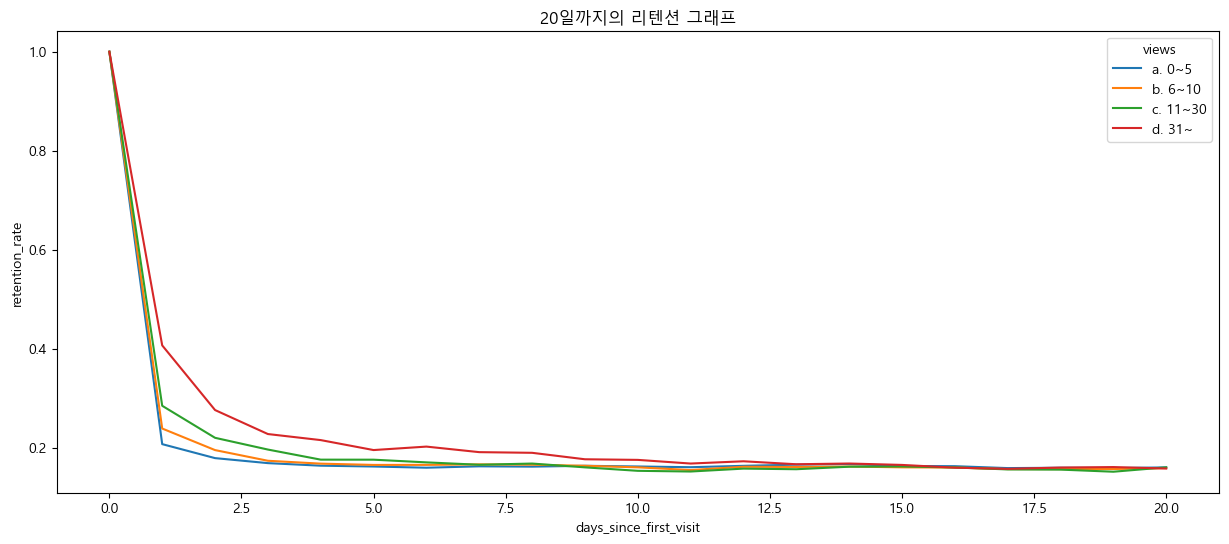

In [54]:
'''
동일한 결과를 출력해주세요
'''

graph_selected_range(cohort_retention_df_input = cohort_retention_rate,
                     day_range=20,
                     days_col = 'days_since_first_visit',
                     retention_col = 'retention_rate',
                     view_col = 'views',
                     title_text='20일까지의 리텐션 그래프')

- 그래프 제목 설정 및 그래프의 세부 요소 구현을 위해 함수 외에 별도의 코드를 작성할 경우 오답으로 처리됩니다.

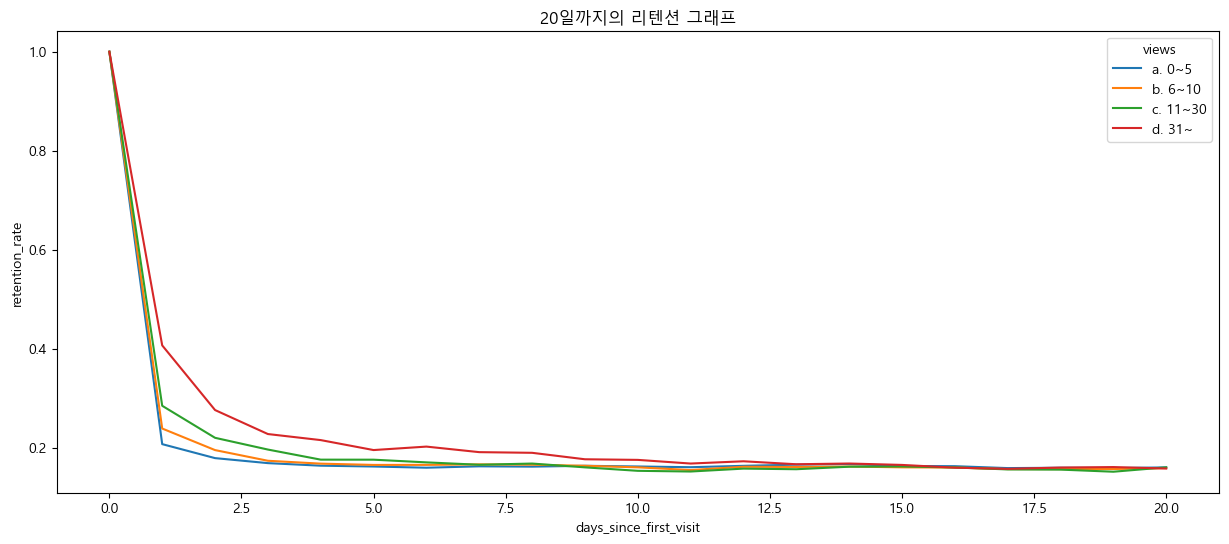

In [55]:
'''
csv 파일을 사용한 경우입니다.
'''
cohort_retention_rate_csv = pd.read_csv('./data_result/Q6_result.csv')
graph_selected_range(cohort_retention_df_input = cohort_retention_rate_csv,
                     day_range=20,
                     days_col = 'days_since_first_visit',
                     retention_col = 'retention_rate',
                     view_col = 'views',
                     title_text='20일까지의 리텐션 그래프')

- 설정된 제목이 없는 경우의 함수의 출력결과입니다.
- 제목이 어떻게 설정되어 있는지 정확하게 확인하시길 바랍니다.
- 그래프 제목 설정 및 그래프의 세부 요소 구현을 위해 함수 외에 별도의 코드를 작성할 경우 오답으로 처리됩니다.

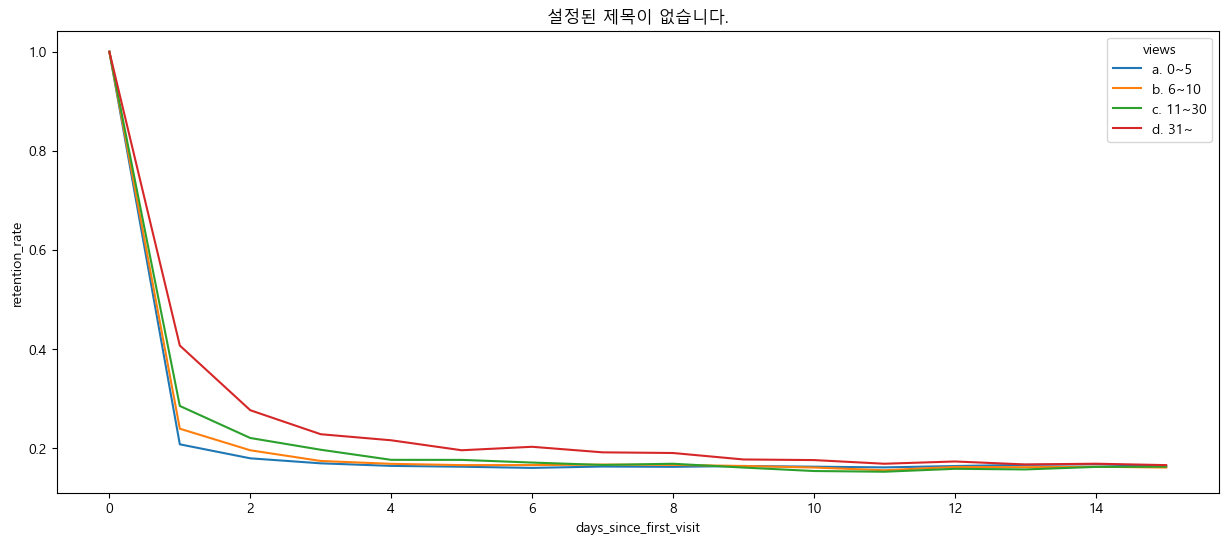

In [56]:
'''
동일한 결과를 출력해주세요
'''

graph_selected_range(cohort_retention_df_input = cohort_retention_rate,
                     day_range=15,
                     days_col = 'days_since_first_visit',
                     retention_col = 'retention_rate',
                     view_col = 'views')

- 설정된 제목이 없는 경우의 함수의 출력결과입니다.
- 제목이 어떻게 설정되어 있는지 정확하게 확인하시길 바랍니다.
- 그래프 제목 설정 및 그래프의 세부 요소 구현을 위해 함수 외에 별도의 코드를 작성할 경우 오답으로 처리됩니다.

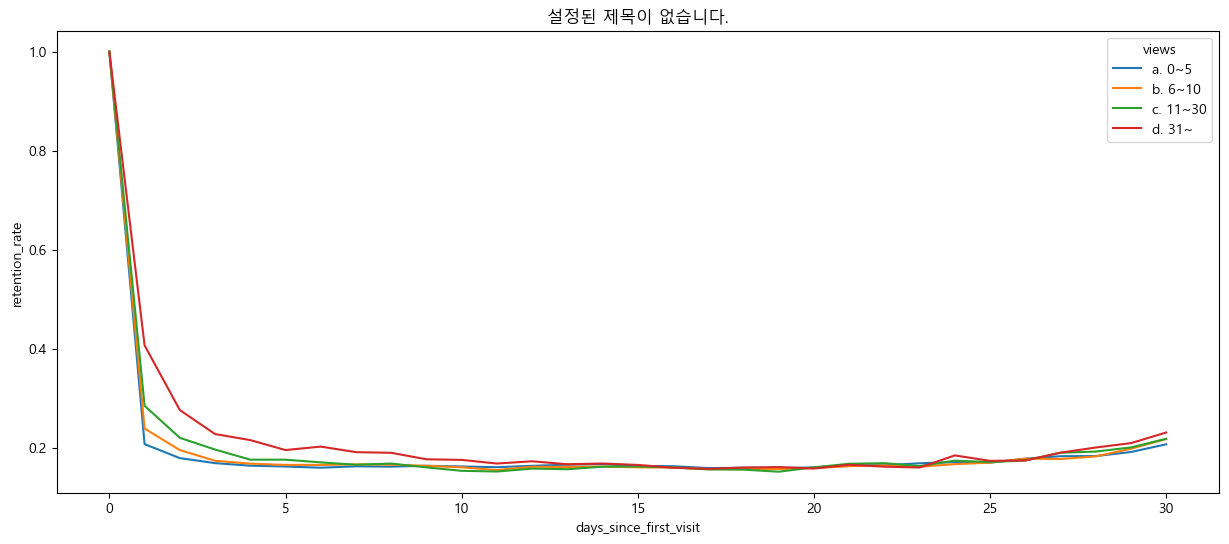

In [57]:
graph_selected_range(cohort_retention_df_input = cohort_retention_rate,
                     day_range=30, # 설정된 제목이 없는 경우
                     days_col = 'days_since_first_visit',
                     retention_col = 'retention_rate',
                     view_col = 'views')

## Q8~Q9. 클래스를 통한 퍼널 분석

### Q8. 클래스 메서드를 통한 데이터 전처리 및 데이터 탐색

- 하나의 클래스 안에 생성자 메서드 외에 2개의 메서드를 추가로 구현하시면 됩니다.
- 각각의 메서드가 하나의 문제에 해당합니다

- 클래스 이름 Funnel_Data_Analysis
    - 동일 클래스 내에 아래의 메서드들을 구현
    
- 사용 데이터
    - web_log_data.csv

- 생성자 메서드
    - 입력된 데이터프레임을 인스턴스 속성(df)에 할당
    - 입력인자 : 데이터프레임

- 문제 8. Execute_EDA 메서드
    - 입력된 데이터프레임 분석 및 전처리 작업
    - 입력인자
        - 이벤트 타입 컬럼 이름
    - event_type별로 해당 이벤트가 몇 번 발생했는지 확인 및 시각화
    - 'rate'
        - event_type별 발생 비율  
        - ※ 데이터 컬럼 생성 과정은 메서드 내에서 이루어져야 하며, 외부에서 컬럼을 추가하여 진행할 경우 오답으로 
    처리됩니다.    

    - 참고    
        - 컬럼명/컬럼순서도 동일하게 만들어주시길 바랍니다.

### Q9. 클래스 메서드를 통한 퍼널 시각화

- 문제 9. Funnel_Graph
    - 클래스 메서드를 통한 퍼널 시각화
    - 퍼널 차트 생성
    - 입력인자
        - 없음
    - 소수점 두 번째 자릿수까지 출력

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
plt.rc('font', family='Malgun Gothic')

class Funnel_Data_Analysis:
    def __init__(self, df):
        ''' 정답 작성을 수행해주세요 '''
        self.df = df # 인스턴스 속성 - df

    def Execute_EDA(self, event_col): # 클래스 메서드를 통한 데이터 탐색
        # Q7. 클래스 메서드를 통한 데이터 전처리 및 데이터 탐색을 진행해주세요
        ''' 정답 코드 작성을 수행해주세요 '''
        self.event_col = event_col
        # display('데이터 탐색 시작')
        # display('상단 5개 데이터')
        # display(self.df.head())

        self.event_df = self.df[self.event_col].value_counts().reset_index() # 인스턴스 속성 - event_df
        # display(self.event_df)
        self.event_df['rate'] = self.event_df['count']/self.event_df['count'].iloc[0] # 이벤트별 발생 비율 확인

        display('이벤트 타입별 발생횟수/비율 확인')
        display(self.event_df)
        plt.title('이벤트 타입별 발생 횟수 - barplot')
        sns.barplot(x=self.event_col, y='count', data=self.event_df)
        plt.show()

    def Funnel_Graph(self): #
        # Q8. 클래스 메서드를 통한 퍼널 시각화를 진행해주세요
        ''' 정답 코드 작성을 수행해주세요 '''
        fig = px.funnel(data_frame=self.event_df, x=self.event_col, y='rate')
        fig.update_traces(texttemplate="%{value:,.2%}") # 소수점 두 자릿수까지 출력
        fig.show()

**Q8 메서드 실행 결과입니다.**
- 결과가 동일하면 정답으로 인정합니다.
    - 데이터프레임 출력, 시각화 출력까지 한 번에 수행되어야 합니다.

'이벤트 타입별 발생횟수/비율 확인'

,event_type,count,rate
0,view,6379532,1.000000
1,cart,124252,0.019477
2,purchase,106966,0.016767


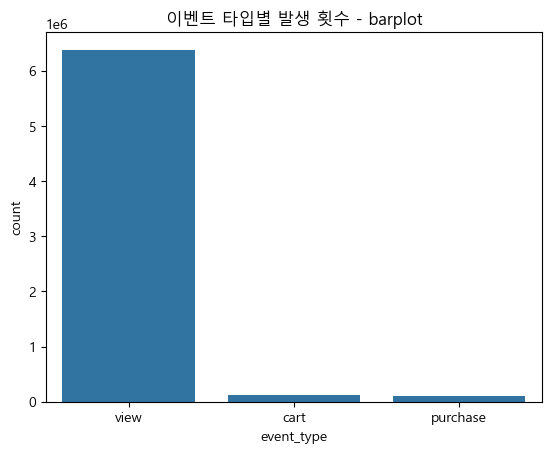

In [62]:
import pandas as pd
tmp_df = pd.read_csv('./data_과제/데이터셋_태블로_웹로그_강의/web_log_data.csv')
data_class = Funnel_Data_Analysis(df=tmp_df)

data_class.Execute_EDA(event_col= 'event_type')

**Q9 메서드 실행 결과입니다.**
- **참고**
    - 색상은 정답과 무관
    - 숫자 형식은 통일
    - 그래프 이미지가 보이지 않을 경우,  
    "Q9_참고이미지.png" 이미지를 참고하시거나 VS Code 등의 로컬 환경에서 확인을 부탁드립니다.
    - 그래프의 방향이 다르게 출력되었을 경우, 오답으로 처리됩니다.

- **확인사항**
    - 메서드 : Funnel_Graph 메서드
    - 목표 : 퍼널 차트 생성
    - 입력인자 : 없음  
    - 조간 : 소수점 두 번째 자릿수까지 출력

In [63]:
data_class.Funnel_Graph()

![이미지 설명](./Q9_참고이미지.png)

## Q10. Tableau 과제 수행

- 첨부드린 PDF를 참고하여 Tableau 결과물을 제출해주세요

- Tableau 과제의 경우, 데이터를 "공공데이터 포털"에서 다운받는 것이 아닌 제공드린 csv 혹은 xlsx 파일을 통해 해결하셔야 합니다.

- 과제 제작에서는 Tableau Public의 데스크탑을 사용했습니다.  

- Tableau 과제 제출 시에는, twbx 파일과 tableau public 링크를 모두 보내주셔야 하며 이를 미준수하여 채점에 문제가 생기는 경우 0점으로 처리됩니다.

※ 주어진 데이터가 아닌 별도의 데이터를 다운하여 문제를 해결할 경우 0점으로 처리됩니다.

## **🔎 [주관식 과제 수행 시 유의사항]**

> **✅ 1. 정확한 출력값과 요구사항 이행 필수**  

주관식 채점은 다음 기준에 따라 평가됩니다.

1)출력 결과의 정확성  
- 제공된 예시 결과와 동일한 출력이 나와야 합니다.  
- 단, 실시간 데이터나 인공지능 학습 등으로 출력값에 변동성이 존재할 수 있는 문제는 예외로 처리합니다.  

2)문제 요구사항의 충실한 반영  
- 조건, 컬럼명, 출력 형식 등 모든 요구사항을 빠짐없이 반영해야 합니다.  
- 사소한 조건도 놓치지 않도록 세심하게 코드를 작성해 주세요.  


> **✅ 2. 완성된 코드 제출 필수**

가. 제출한 코드 셀은 채점 시 직접 실행하여 결과를 확인할 수 있습니다.  

- 재실행 시에도 동일한 결과가 나와야 정답으로 인정됩니다.  

나. 버전 차이에 따른 미세한 수치 차이는 감안하나, 결과 형태나 구조가 다르면 감점 또는 오답 처리될 수 있습니다.  

다. 시각화 문제에서 색상 지정이 없다면, 기본(default) 색상 사용을 전제로 합니다.  
- 환경에 따라 색상이 다르게 출력되더라도 불이익은 없습니다.  

> **✅ 3. 사용자 선언 함수/클래스 문제 주의사항**

사용자 정의 함수, 클래스, 메서드와 관련된 문제에서는 추가적인 코드 없이도 함수만으로 정답 결과가 도출되어야 합니다.  
- ❌ 함수 외부에서 plt.title, print, info() 등을 추가하여 결과를 보완하면 오답 처리됩니다.  

> **✅ 4. 함수/클래스 선언 시 일관된 결과 유지**

가. 함수, 클래스, 메서드는 반복 실행 시에도 항상 동일한 결과를 반환해야 합니다.  
나. 채점 중 재실행 결과가 다르면 오답으로 처리됩니다.  

> **📌 [안내 정리]**  

가. 문제의 모든 조건을 꼼꼼히 확인하고 반영해 주세요.  
나. 과제는 실무와 유사한 기준으로 평가되며, 요구 조건을 충족하지 않을 경우 0점 처리될 수 있습니다.  